In [1]:
import scipy.io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from random import shuffle
from resources.lattices import geometry, pStrainProperties, effProperties
from resources.calculations import calcUT, calcFT

In [2]:
### GLOBAL PATH INPUTS

pData = 'data/'

pAl          = pData + 'Al/'
pAK          = pAl + 'AK/'
pUTdisNodes  = pAK + 'Ductile-disNodes-FCC-12X16/'
pUTdisStruts = pAK + 'Ductile-disStruts-FCC-12X16/'
pFTdisNodes  = pAK + 'Fracture-disNodes/'

pTi    = pData + 'Ti/'
pTiTri = pTi + 'tri/'
pTiKag = pTi + 'kagome/'
pTiFCC = pTi + 'FCC/'
pTiHex = pTi + 'hex/'

# Load Data

In [23]:
PATH  = pUTdisNodes
dis   = 'disNodes'     # disNodes, disStruts

UT_CSVin  = PATH + f'Ductile-{dis}-IN.csv'
UT_CSVout = PATH + f'Ductile-{dis}-OUT.csv'
perIN = PATH + f'raw\IN-Ductile-FCC-12X16-per-1.txt'
perOUT = PATH + f'raw\OUT-Ductile-FCC-12X16-per-1.txt'

In [56]:
def load_AKdata(inputs, outputs, perIN, perOUT):
    dIN_df = pd.read_csv(inputs, index_col=0)
    dOUT_df = pd.read_csv(outputs, index_col=0)
    
    perIN_df = pd.DataFrame(pd.read_csv(perIN, header=None, index_col=0).to_numpy().flatten())
    perOUT_df = pd.read_csv(perOUT, names=['e', 's'], index_col=0, delimiter=' ')
    print(perIN_df.to_list())
    IN_df = dIN_df + perIN_df.to_numpy()
    OUT_df = dOUT_df + perOUT_df.s.to_numpy()
    
    return IN_df, OUT_df, perIN_df, perOUT_df, dIN_df, dOUT_df

In [57]:
IN_df, OUT_df, perIN_df, perOUT_df, dIN_df, dOUT_df = load_AKdata(UT_CSVin, UT_CSVout, perIN, perOUT)

AttributeError: 'DataFrame' object has no attribute 'to_list'

# Geometry

In [14]:
LAT = 'FCC'
l = 0.010
nnx = 12
nny = 18

# Prep Data

In [7]:
def prep_UTdata(dIN_df, dOUT_df):
    dIN = dIN_df.to_numpy()
    dOUT = dOUT_df.to_numpy()
#     xOUT = np.linspace(0, max(perOUT_df.x.tolist()), len(dOUT[0]))
    
#     ducts, strens, stiffs = [], [], []
#     for i, row in OUT_df.iterrows():
#         UT_df = pd.DataFrame({'x':np.insert(xOUT,0,row[0]), 'y_sm':row})
#         ductility, strength, stiffness = calcUT(UT_df)
        
#         ducts.append(ductility)
#         strens.append(strength)
#         stiffs.append(stiffness)
        
#     props = [ducts, strens, stiffs]
    return dIN, dOUT#, xOUT, props

def find_outliers(data):
    mean = np.mean(data)
    stdev = np.std(data)
    
    outlier_idxs = [data.index(x) for x in data if (x < mean - 4*stdev) or (x > mean + 4*stdev) if data.index(x) != 0]
    return np.array(outlier_idxs, dtype="int")

def remove_outliers(dIN_r, dOUT_r, props_r, IN_df, OUT_df, dIN_df, dOUT_df):
    all_outlier_idxs = []
    for prop_r in props_r:
        idxs = find_outliers(data=prop_r)
        if len(idxs) == 0:
            continue
        for idx in idxs:
            all_outlier_idxs.append(idx)
    outlier_idxs = np.array(list(set(all_outlier_idxs)))
    
    if len(outlier_idxs) > 0:
        dIN = np.delete(dIN_r, outlier_idxs, axis=0)
        dOUT = np.delete(dOUT_r, outlier_idxs, axis=0)
        IN_df = IN_df.drop(IN_df.iloc[outlier_idxs].index)
        OUT_df = OUT_df.drop(OUT_df.iloc[outlier_idxs].index)
        dIN_df = dIN_df.drop(dIN_df.iloc[outlier_idxs].index)
        dOUT_df = dOUT_df.drop(dOUT_df.iloc[outlier_idxs].index)
        props = []
        for prop_r in props_r:
            prop = np.delete(prop_r, outlier_idxs, axis=0)
            props.append(prop)
    else:
        dIN, dOUT, props = dIN_r, dOUT_r, props_r
    
    return dIN, dOUT, props, IN_df, OUT_df, dIN_df, dOUT_df

def split_data(dIN, dOUT, split=0.85):
    idxs = list(range(len(dOUT)))
    shuffle(idxs)
    train_idxs = idxs[:int(split*len(dOUT))]
    test_idxs = [i for i in idxs if i not in train_idxs]
    
    train_in = dIN[train_idxs]
    test_in = dIN[test_idxs]
    train_out = dOUT[train_idxs]
    test_out = dOUT[test_idxs]
    
    return train_in, train_out, test_in, test_out

In [9]:
if MODEL.lower() == "ductile" or MODEL.lower() == "both":
    UT_dIN, UT_dOUT = prep_UTdata(UT_dIN_df, UT_dOUT_df)
    #UT_dIN, UT_dOUT, UT_props, UT_IN_df, UT_OUT_df, UT_dIN_df, UT_dOUT_df = remove_outliers(UT_dIN_r, UT_dOUT_r, UT_props_r, UT_IN_df, UT_OUT_df, UT_dIN_df, UT_dOUT_df)
    UT_train_in, UT_train_out, UT_test_in, UT_test_out = split_data(UT_dIN[1:], UT_dOUT[1:], split=0.85)

if MODEL.lower() == "fracture" or MODEL.lower() == "both":
    FT_dIN_r, FT_dOUT_r, FT_xOUT, FT_props_r = prep_FTdata(FT_dIN_df, FT_dOUT_df, FT_perOUT_df, FT_OUT_df, geom, E_eff)
    FT_dIN, FT_dOUT, FT_props, FT_IN_df, FT_OUT_df, FT_dIN_df, FT_dOUT_df = remove_outliers(FT_dIN_r, FT_dOUT_r, FT_props_r, FT_IN_df, FT_OUT_df, FT_dIN_df, FT_dOUT_df)
    FT_train_in, FT_train_out, FT_test_in, FT_test_out = split_data(FT_dIN[1:], FT_dOUT[1:], split=0.85)

In [10]:
UT_dOUT

array([[-0.00065226,  0.06339717,  0.12822165, ...,  0.01597023,
         0.02379994,  0.02835034],
       [-0.0006748 ,  0.06487473,  0.12929266, ...,  0.11795604,
         0.01269063,  0.09922882],
       [-0.00065365,  0.06500815,  0.12914114, ...,  0.11250267,
         0.15179983,  0.09871647],
       ...,
       [-0.00066653,  0.06438909,  0.12930622, ...,  0.16543707,
         0.10545864,  0.18112087],
       [-0.00064832,  0.06398321,  0.1301155 , ...,  0.13095858,
         0.17999935,  0.07223319],
       [-0.00066904,  0.06348706,  0.1289104 , ...,  0.04675726,
         0.00357146,  0.07510711]])

In [11]:
def locSims(prop, OUT_df):
    max_idx, min_idx = prop.index(max(prop[1:])), prop.index(min(prop[1:]))
    nSim_max, nSim_min = OUT_df.iloc[max_idx].name, OUT_df.iloc[min_idx].name
    return nSim_max, nSim_min

if MODEL.lower() == "ductile" or MODEL.lower() == "both":
    UT_nSim_max, UT_nSim_min = locSims(UT_props[0], UT_OUT_df)
    print(f"UT -- max: {UT_nSim_max}, min: {UT_nSim_min}")
if MODEL.lower() == "fracture" or MODEL.lower() == "both":
    FT_nSim_max, FT_nSim_min = locSims(FT_props[0], FT_OUT_df)
    print(f"FT -- max: {FT_nSim_max}, min: {FT_nSim_min}")

NameError: name 'UT_props' is not defined

In [12]:
def plot_frequency(raw_data, data, test):
    raw_data = np.array(data)
    data = np.array(data)
    
    if test == "UT":
        x_label = 'Normalized Ductility'
    elif test == "FT":
        x_label = 'Normalized Fracture Toughness ($K_{IC}$)'
    
    fig1, (ax1, ax2) = plt.subplots(1, 2)
    fig1.set_figheight(5)
    fig1.set_figwidth(15)
    
    ax1.set_title('Raw Data')
    ax1.axvline(x=raw_data[0]/raw_data[0], color='orangered', label="Perfect")
    ax1.hist(raw_data[1:]/raw_data[0], bins=int(len(data)/5), label='Disordered')
    ax1.set_ylabel('Frequency')
    ax1.set_xlabel(x_label)
    ax1.legend()
    
    ax2.set_title('Without Outliers')
    ax2.axvline(x=data[0]/data[0], color='orangered', label="Perfect")
    ax2.hist(data[1:]/data[0], bins=int(len(data)/5), label='Disordered')
    ax2.set_ylabel('Frequency')
    ax2.set_xlabel(x_label)
    ax2.legend()
    
    plt.show()

def plot_properties(x_data, y_data, test):
    x_data = np.array(x_data)
    y_data = np.array(y_data)
    
    if test == "UT":
        title = "Uniaxial Tension"
        x_label = 'Normalized Ductility'
        y_label = 'Normalized Strength'
    elif test == "FT":
        title = "Compact Tension"
        x_label = 'Normalized Fracture Toughness ($K_{IC}$)'
        y_label = 'Normalized Displacement'
    
    fig1, ax1 = plt.subplots(1, 1)
    fig1.set_figheight(5)
    fig1.set_figwidth(10)
    
    ax1.set_title(title)
    ax1.scatter(x_data[0]/x_data[0], y_data[0]/y_data[0], label='Perfect')
    ax1.scatter(x_data[1:]/x_data[0], y_data[1:]/y_data[0], label='Disordered')
    ax1.axvline(x=1, linestyle='--')
    ax1.axhline(y=1, linestyle='--')
    ax1.set_ylabel(y_label)
    ax1.set_xlabel(x_label)
    ax1.legend()
    
    plt.show()

In [13]:
plot_freq = True
plot_props = True

dduct, sstr, sstiff = 0, 1, 2
kk, FF, dd = 0, 2, 3

U1, U2 = dduct, sstr
F1, F2 = kk, dd

if plot_freq:
    if MODEL.lower() == "ductile" or MODEL.lower() == "both":
        plot_frequency(UT_props_r[U1], UT_props[U1], "UT")
    if MODEL.lower() == "fracture" or MODEL.lower() == "both":
        plot_frequency(FT_props_r[F1], FT_props[F1], "FT")

if plot_props:
    if MODEL.lower() == "ductile" or MODEL.lower() == "both":
        plot_properties(UT_props[U1], UT_props[U2], "UT")
    if MODEL.lower() == "fracture" or MODEL.lower() == "both":
        plot_properties(FT_props[F1], FT_props[F2], "FT")

NameError: name 'UT_props_r' is not defined

In [54]:
UT_OUT_df

,0,1,2,3,4,5,6,7,8,9,...,192,193,194,195,196,197,198,199,200,201
0,122.0,0.0,3.390623,6.822201,10.254927,13.675207,17.085792,20.518387,23.936351,27.318691,...,0.887079,0.814409,0.611172,0.688988,0.620182,0.532896,0.491399,0.563662,0.592062,0.748483
1,90.0,0.0,3.349671,6.751778,10.142601,13.516430,16.914891,20.318570,23.687265,27.051273,...,-0.014248,-0.106453,-0.126699,-0.113584,-0.089292,-0.084499,-0.085646,-0.161864,-0.281769,-0.473207
2,97.0,0.0,3.351872,6.757169,10.151763,13.526062,16.930118,20.335352,23.708056,27.072037,...,-0.150438,0.030915,0.161283,0.258661,0.270317,0.315331,0.288063,0.387025,0.480611,0.852975
3,89.0,0.0,3.354182,6.753928,10.142353,13.510777,16.902439,20.300381,23.663222,27.021911,...,0.264333,0.233566,0.205491,0.220303,0.164527,0.162392,0.028704,-0.296721,-0.657455,-1.396075
4,97.0,0.0,3.348903,6.747110,10.135034,13.506796,16.903520,20.306765,23.673847,27.035207,...,-0.062881,-0.104113,-0.178953,-0.227925,-0.259576,-0.256315,-0.275788,-0.189683,-0.117630,0.197381
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,88.0,0.0,3.357653,6.760976,10.153414,13.524687,16.921165,20.321250,23.686816,27.045922,...,0.107303,0.129323,0.209488,0.177450,0.150212,0.110248,0.035294,-0.021169,-0.064416,0.170381
97,90.0,0.0,3.355667,6.758981,10.149723,13.518853,16.920948,20.324233,23.689145,27.054509,...,0.003742,0.055826,0.079739,0.089964,0.094581,0.079671,0.051397,-0.006206,-0.069306,-0.209253
98,92.0,0.0,3.332364,6.724473,10.107893,13.477604,16.870673,20.277883,23.639314,26.997203,...,0.228536,0.157556,0.100985,0.022749,0.033732,-0.002206,-0.036370,-0.030644,-0.051424,0.097061
99,79.0,0.0,3.341329,6.744224,10.133679,13.506889,16.913481,20.318887,23.684387,27.049030,...,-0.099035,0.012668,0.109369,0.103156,0.045296,-0.099772,-0.206141,-0.201053,-0.229517,0.121302


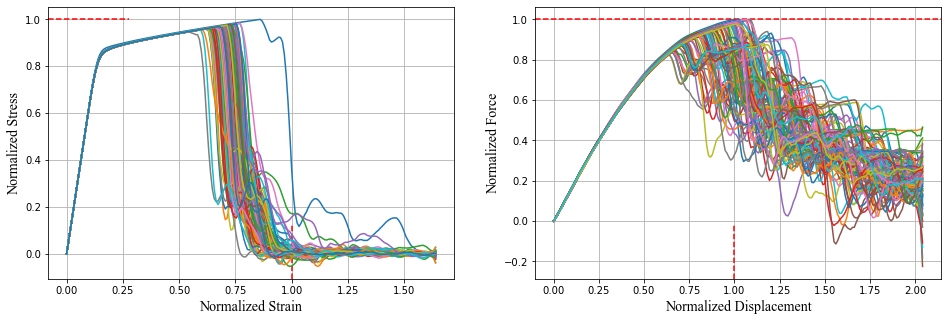

In [55]:
def plot_curve(UT_OUT_df, UT_xOUT, FT_OUT_df, FT_xOUT, idx=None, q=15):
    fig2, (ax1, ax2) = plt.subplots(1, 2)
    fig2.set_figheight(5)
    fig2.set_figwidth(16)
    
    if MODEL.lower() == "ductile" or MODEL.lower() == "both":
        UTp = UT_OUT_df.loc[0].tolist()[1:]
        UTindx = int(UT_OUT_df.loc[0].tolist()[0])
        ax1.plot(UT_xOUT/UT_xOUT[UTindx], [i/max(UTp) for i in UTp], label="Perfect")
        ax1.axvline(x=1, ymax=0.2, c='r', linestyle='--')
        ax1.axhline(y=1, xmax=0.2, c='r', linestyle='--')

    if MODEL.lower() == "fracture" or MODEL.lower() == "both":
        FTp = FT_OUT_df.loc[0].tolist()[1:]
        FTindx = int(FT_OUT_df.loc[0].tolist()[0])
        ax2.plot(FT_xOUT/FT_xOUT[FTindx], [i/FTp[FTindx] for i in FTp], label="Perfect")
        ax2.axvline(x=1, ymax=0.2, c='r', linestyle='--')
        ax2.axhline(y=1, xmax=2, c='r', linestyle='--')
    
    if idx:
        if MODEL.lower() == "ductile" or MODEL.lower() == "both":
            UTd = UT_OUT_df.loc[idx].tolist()[1:]
            UTindx2 = int(UT_OUT_df.loc[idx].tolist()[0])
            ax1.plot(UT_xOUT/UT_xOUT[UTindx], [i/max(UTp) for i in UTd], label=f'Disordered{idx}')
            ax1.axvline(x=UT_xOUT[UTindx2]/UT_xOUT[UTindx], ymax=0.2, c='g', linestyle='--')
            ax1.axhline(y=max(UTd)/max(UTp), xmax=0.2, c='g', linestyle='--')
        
        if MODEL.lower() == "fracture" or MODEL.lower() == "both":
            FTd = FT_OUT_df.loc[idx].tolist()[1:]
            FTindx2 = int(FT_OUT_df.loc[idx].tolist()[0])
            ax2.plot(FT_xOUT/FT_xOUT[FTindx], [i/FTp[FTindx] for i in FTd], label=f'Disordered{idx}')
            ax2.axvline(x=FT_xOUT[FTindx2]/FT_xOUT[FTindx], ymax=0.2, c='g', linestyle='--')
            ax2.axhline(y=FTd[FTindx2]/FTp[FTindx], xmax=0.2, c='g', linestyle='--')
        
    else:
        if MODEL.lower() == "ductile" or MODEL.lower() == "both":
            UT_idxs = UT_OUT_df.index.tolist()[1:]
        if MODEL.lower() == "fracture" or MODEL.lower() == "both":
            FT_idxs = FT_OUT_df.index.tolist()[1:]
        if q == 'all':
            if MODEL.lower() == "ductile" or MODEL.lower() == "both":
                UT_idxs = UT_idxs
            if MODEL.lower() == "fracture" or MODEL.lower() == "both":
                FT_idxs = FT_idxs
        else:
            if MODEL.lower() == "ductile" or MODEL.lower() == "both":
                UT_idxs = random.sample(UT_idxs, q)
                print(UT_idxs)
            if MODEL.lower() == "fracture" or MODEL.lower() == "both":
                FT_idxs = random.sample(FT_idxs, q)
                print(FT_idxs)
        
        if MODEL.lower() == "ductile" or MODEL.lower() == "both":
            for idx in UT_idxs:
                UTd = UT_OUT_df.loc[idx].tolist()[1:]
                ax1.plot(UT_xOUT/UT_xOUT[UTindx], [i/max(UTp) for i in UTd], label=f'Disordered{idx}')
        if MODEL.lower() == "fracture" or MODEL.lower() == "both":
            for idx in FT_idxs:
                FTd = FT_OUT_df.loc[idx].tolist()[1:]
                FTindx = int(FT_OUT_df.loc[0].tolist()[0])
                ax2.plot(FT_xOUT/FT_xOUT[FTindx-1], [i/FTp[FTindx-1] for i in FTd], label=f'Disordered{idx}')
    
    ax1.set_ylabel('Normalized Stress', fontsize=14, fontname="Times New Roman")
    ax1.set_xlabel('Normalized Strain', fontsize=14, fontname="Times New Roman")
    #ax1.legend()
    ax1.grid()
    
    ax2.set_ylabel('Normalized Force', fontsize=14, fontname="Times New Roman")
    ax2.set_xlabel('Normalized Displacement', fontsize=14, fontname="Times New Roman")
    #ax2.legend()
    ax2.grid()
    
    plt.show()

plot_curve(UT_OUT_df, UT_xOUT, FT_OUT_df, FT_xOUT, idx=None, q='all') # figure out why perfect lattice weird